# Autoencoders From Scratch 
Dataset: `sklearn.load_digits` — `8 x 8 = 64`-pixel handwritten digits (a tiny MNIST), so every model trains in seconds.

## Contents

0. Setup and data
1. **Introduction to Autoencoders** — what an autoencoder is, the two maps, undercomplete vs overcomplete
2. **Choice of Decoder and Loss Function** — binary vs real-valued inputs
3. **Link between PCA and Autoencoders** — the proof, then a numerical verification
4. **Regularisation in Autoencoders** — why it is needed; $L_2$ + weight tying
5. **Denoising Autoencoders** — corrupt the input, reconstruct the clean target
6. **Sparse Autoencoders** — the KL-divergence sparsity penalty
7. **Contractive Autoencoders** — the Jacobian (Frobenius) penalty

Summary — the big picture in one table

In [8]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 0. Setup and Data

Each image is flattened to a vector $x_i \in \mathbb{R}^{64}$, scaled to $[0,1]$. Stacking $m$ images gives the data matrix

$$X \in \mathbb{R}^{m \times n}, \qquad m = \text{number of images}, \quad n = 64 \text{ pixels}.$$

Pixel values in $[0,1]$ let us read a sigmoid output as a probability (useful in chapter 2).

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

digits = load_digits()
IMG = (8, 8)
X = digits.images.reshape(len(digits.images), -1) / 16.0   # -> [0,1], shape (1797, 64)
y = digits.target

print("Data matrix X:", X.shape, " pixel range:", (X.min(), X.max()))
print("n =", X.shape[1], "pixels   m =", X.shape[0], "images")

Data matrix X: (1797, 64)  pixel range: (np.float64(0.0), np.float64(1.0))
n = 64 pixels   m = 1797 images


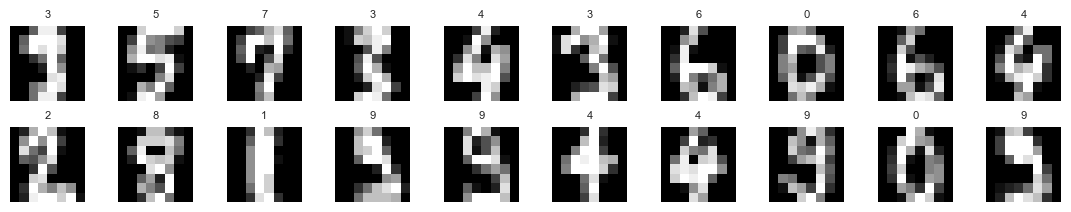

Twenty sample digits (the inputs an autoencoder will try to copy through a bottleneck).


In [10]:
def show_grid(rows_of_images, titles=None, ncols=10, scale=1.1, cmap="gray"):
    imgs = np.asarray(rows_of_images)
    n = len(imgs); nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*scale, nrows*scale))
    axes = np.atleast_1d(axes).ravel()
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(imgs[i].reshape(IMG), cmap=cmap)
            if titles is not None: ax.set_title(str(titles[i]), fontsize=8)
    plt.tight_layout(); plt.show()

idx = rng.choice(len(X), 20, replace=False)
show_grid(X[idx], titles=y[idx])
print("Twenty sample digits (the inputs an autoencoder will try to copy through a bottleneck).")

## 1. Introduction to Autoencoders

An **autoencoder** is a feed-forward network that learns to *copy its input to its output* through a compressed intermediate representation. It does two things:

- **Encode:** map the input $x_i$ to a hidden code $h$.
- **Decode:** reconstruct the input from $h$, producing $\hat x_i$.

The two maps are

$$h = g(W x_i + b), \qquad \hat x_i = f(W^{*} h + c),$$

with $x_i \in \mathbb{R}^{n}$, $h \in \mathbb{R}^{d}$, $W \in \mathbb{R}^{d \times n}$, $W^{*} \in \mathbb{R}^{n \times d}$. Here $g$ is the **encoder** nonlinearity and $f$ the **decoder** nonlinearity. Training minimises a loss that forces $\hat x_i \approx x_i$, so the bottleneck $h$ is pressured to keep *everything needed to rebuild $x_i$* — and nothing else.

### Undercomplete vs overcomplete

| | condition | what happens |
|---|---|---|
| **Undercomplete** | $\dim(h) < \dim(x)$ | a real bottleneck → must throw away noise / redundancy → behaves like PCA (chapter 3) |
| **Overcomplete** | $\dim(h) \ge \dim(x)$ | network can cheat by learning the **identity** ($x \to h \to \hat x$), which teaches nothing → we *must* regularise (chapters 4–7) |

The whole second half of the lecture exists because of that overcomplete failure mode: a perfect copy has **zero reconstruction error but zero insight**. Regularisation is what stops the copy.

## The Engine — one from-scratch autoencoder, reused everywhere

Below is a single one-hidden-layer autoencoder with **all gradients written by hand** (no autograd). Every regularised variant in chapters 3–7 is just this class with a different switch:

- `enc`, `dec` — encoder/decoder activation (`"sigmoid"` or `"linear"`)
- `loss` — `"squared"` (real inputs) or `"cross_entropy"` (binary/probabilistic)
- `alpha` — $L_2$ weight-decay strength
- `tied` — enforce $W^{*} = W^{\top}$ (weight tying)
- `denoise_p` — corrupt the input before feeding it in (denoising AE)
- `rho`, `beta` — target sparsity and KL penalty strength (sparse AE)
- `lam_contractive` — Jacobian penalty strength (contractive AE)

The backprop seed gradients used below:

$$\text{squared loss: } \frac{\partial L}{\partial \hat x} = \tfrac{2}{m}(\hat x - x), \qquad \text{sigmoid + cross-entropy: } \frac{\partial L}{\partial a_2} = \tfrac{1}{m}(\hat x - x).$$

The second identity is the clean, classic result — the sigmoid derivative and the cross-entropy derivative cancel.

In [11]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -50, 50)))

# activation -> (function, derivative expressed in terms of the OUTPUT h)
ACT = {
    "sigmoid": (sigmoid, lambda h: h * (1.0 - h)),
    "linear":  (lambda z: z, lambda h: np.ones_like(h)),
}

class Autoencoder:
    """One hidden layer. Encoder W (d x n), decoder W* (n x d). Hand-written gradients."""
    def __init__(self, n_in, n_hidden, enc="sigmoid", dec="sigmoid",
                 loss="cross_entropy", alpha=0.0, tied=False,
                 denoise_p=0.0, denoise_kind="mask",
                 rho=None, beta=0.0, lam_contractive=0.0, seed=0):
        r = np.random.default_rng(seed)
        s = np.sqrt(6.0 / (n_in + n_hidden))                 # Glorot init
        self.W     = r.uniform(-s, s, (n_hidden, n_in))
        self.b     = np.zeros(n_hidden)
        self.Wstar = r.uniform(-s, s, (n_in, n_hidden))
        self.c     = np.zeros(n_in)
        self.enc_name, self.dec_name = enc, dec
        self.enc_f, self.enc_df = ACT[enc]
        self.dec_f, self.dec_df = ACT[dec]
        self.loss, self.alpha, self.tied = loss, alpha, tied
        self.denoise_p, self.denoise_kind = denoise_p, denoise_kind
        self.rho, self.beta, self.lam = rho, beta, lam_contractive

    # ---- forward ----
    def encode(self, X):
        return self.enc_f(X @ self.W.T + self.b)

    def forward(self, X):
        Wstar = self.W.T if self.tied else self.Wstar
        A1 = X @ self.W.T + self.b;  H = self.enc_f(A1)
        A2 = H @ Wstar.T + self.c;   Xhat = self.dec_f(A2)
        return A1, H, A2, Xhat

    # ---- losses (for monitoring / grad-checking) ----
    def _recon(self, X, Xhat):
        m = X.shape[0]
        if self.loss == "squared":
            return np.sum((Xhat - X) ** 2) / m
        eps = 1e-9
        return -np.sum(X*np.log(Xhat+eps) + (1-X)*np.log(1-Xhat+eps)) / m

    def contractive_value(self, X):
        H = self.encode(X)                         # only meaningful for sigmoid encoder
        return np.sum(((H*(1-H))**2) * np.sum(self.W**2, axis=1)) / X.shape[0]

    def loss_value(self, X_clean, X_in=None):
        X_in = X_clean if X_in is None else X_in
        _, H, _, Xhat = self.forward(X_in)
        L = self._recon(X_clean, Xhat)
        if self.alpha:
            P = self.W.ravel() if self.tied else np.concatenate([self.W.ravel(), self.Wstar.ravel()])
            L += 0.5 * self.alpha * np.sum(P**2)
        if self.beta and self.rho is not None:
            rh = np.clip(H.mean(0), 1e-6, 1-1e-6)
            L += self.beta * np.sum(self.rho*np.log(self.rho/rh) + (1-self.rho)*np.log((1-self.rho)/(1-rh)))
        if self.lam:
            L += self.lam * self.contractive_value(X_in)
        return L

    # ---- gradients (the heart of the notebook) ----
    def grads(self, X_clean, X_in):
        m = X_clean.shape[0]
        Wstar = self.W.T if self.tied else self.Wstar
        A1 = X_in @ self.W.T + self.b;  H = self.enc_f(A1)
        A2 = H @ Wstar.T + self.c;      Xhat = self.dec_f(A2)

        if self.loss == "cross_entropy" and self.dec_name == "sigmoid":
            dA2 = (Xhat - X_clean) / m                          # sigmoid+CE shortcut
        else:
            dXhat = (2.0/m)*(Xhat - X_clean) if self.loss == "squared" \
                    else (-(X_clean/(Xhat+1e-9)) + (1-X_clean)/(1-Xhat+1e-9))/m
            dA2 = dXhat * self.dec_df(Xhat)

        dWstar = dA2.T @ H
        dc     = dA2.sum(0)
        dH     = dA2 @ Wstar
        dA1    = dH * self.enc_df(H)
        dW     = dA1.T @ X_in
        db     = dA1.sum(0)

        # --- sparsity (KL) penalty flows back through the average activation ---
        if self.beta and self.rho is not None:
            rh = np.clip(H.mean(0), 1e-6, 1-1e-6)
            dkl = (-self.rho/rh + (1-self.rho)/(1-rh))
            dA1_kl = (self.beta/m) * dkl * self.enc_df(H)
            dW += dA1_kl.T @ X_in;  db += dA1_kl.sum(0)

        # --- contractive (Jacobian) penalty: Omega = sum_l [h_l(1-h_l)]^2 ||W_l||^2 ---
        if self.lam:
            g = (H*(1-H))**2                          # (m,d)
            row_sq = np.sum(self.W**2, axis=1)        # (d,)
            dW += (self.lam/m) * (g.sum(0)[:,None] * (2*self.W))           # d/dW of ||W_l||^2
            coef = (2*g*(1-2*H)) * row_sq[None,:]     # d/dW through the activation
            dW += (self.lam/m) * (coef.T @ X_in)
            db += (self.lam/m) * coef.sum(0)

        if self.alpha:
            dW += self.alpha * self.W
            if not self.tied: dWstar += self.alpha * self.Wstar

        if self.tied:
            return {"W": dW + dWstar.T, "b": db, "c": dc}    # W appears in BOTH maps
        return {"W": dW, "b": db, "Wstar": dWstar, "c": dc}

    # ---- training ----
    def _corrupt(self, X, r):
        if self.denoise_kind == "mask":
            return X * (r.random(X.shape) > self.denoise_p)          # flip pixels to 0
        return np.clip(X + r.normal(0, self.denoise_p, X.shape), 0, 1)

    def step(self, g, lr):
        self.W -= lr*g["W"]; self.b -= lr*g["b"]; self.c -= lr*g["c"]
        if not self.tied: self.Wstar -= lr*g["Wstar"]

    def fit(self, X, epochs=300, lr=0.5, batch=128, seed=0, verbose=False):
        r = np.random.default_rng(seed); m = len(X); hist = []
        for ep in range(epochs):
            order = r.permutation(m)
            for s0 in range(0, m, batch):
                xb = X[order[s0:s0+batch]]
                xin = self._corrupt(xb, r) if self.denoise_p > 0 else xb
                self.step(self.grads(xb, xin), lr)
            hist.append(self.loss_value(X))
            if verbose and ep % max(1, epochs//5) == 0:
                print(f"  epoch {ep:4d}   loss {hist[-1]:.4f}")
        return hist


### Gradient check — proof the hand-written backprop is correct

Before trusting a single result, we compare each analytic gradient against a finite-difference estimate $\frac{L(\theta+\epsilon) - L(\theta-\epsilon)}{2\epsilon}$. A relative error below $10^{-4}$ means the math is right.

In [12]:
def gradient_check(ae, Xg, n_samples=40, eps=1e-6):
    g = ae.grads(Xg, Xg)
    params = {"W": ae.W, "b": ae.b, "c": ae.c}
    if not ae.tied: params["Wstar"] = ae.Wstar
    worst = 0.0
    rg = np.random.default_rng(7)
    for name, P in params.items():
        flat = P.ravel()
        for _ in range(n_samples):
            i = rg.integers(flat.size); old = flat[i]
            flat[i] = old + eps; Lp = ae.loss_value(Xg)
            flat[i] = old - eps; Lm = ae.loss_value(Xg)
            flat[i] = old
            num, ana = (Lp - Lm)/(2*eps), g[name].ravel()[i]
            worst = max(worst, abs(num-ana)/max(1e-8, abs(num)+abs(ana)))
    return worst

Xg = rng.random((8, 64))
configs = {
    "cross-entropy + sigmoid"  : dict(loss="cross_entropy", dec="sigmoid"),
    "squared + linear decoder" : dict(loss="squared", dec="linear"),
    "linear encoder+decoder"   : dict(loss="squared", enc="linear", dec="linear"),
    "L2 + weight tying"        : dict(loss="cross_entropy", alpha=0.3, tied=True),
    "sparse (KL)"              : dict(loss="cross_entropy", rho=0.05, beta=0.7),
    "contractive (Jacobian)"   : dict(loss="squared", dec="linear", lam_contractive=0.4),
}
for name, kw in configs.items():
    ae = Autoencoder(64, 30, **kw)
    err = gradient_check(ae, Xg)
    print(f"{name:28s} max rel error = {err:.1e}   {'OK' if err < 1e-4 else 'FAIL'}")

cross-entropy + sigmoid      max rel error = 6.3e-06   OK
squared + linear decoder     max rel error = 1.2e-07   OK
linear encoder+decoder       max rel error = 5.0e-08   OK
L2 + weight tying            max rel error = 6.8e-07   OK
sparse (KL)                  max rel error = 2.2e-07   OK
contractive (Jacobian)       max rel error = 2.2e-07   OK


## 2. Choice of Decoder and Loss Function

Designing an autoencoder needs **two** decisions, and both depend on the *type* of input.

**Binary inputs** $x_{ij} \in \{0,1\}$. A logistic (sigmoid) decoder maps to $(0,1)$ and reads as a probability: output $0.8$ = "$80\%$ sure this pixel is $1$." Pair it with **cross-entropy** loss

$$L = -\frac{1}{m}\sum_{i=1}^{m}\sum_{j=1}^{n}\Big[x_{ij}\log\hat x_{ij} + (1-x_{ij})\log(1-\hat x_{ij})\Big],$$

which is minimised exactly at $\hat x_{ij} = x_{ij}$.

**Real-valued inputs** $x_i \in \mathbb{R}^n$ (e.g. pixel intensities). A sigmoid/tanh decoder would wrongly clamp the output range, so use a **linear** decoder $\hat x_i = W^{*}h + c$ with **squared-error** loss

$$L = \frac{1}{m}\sum_{i=1}^{m}\| \hat x_i - x_i \|^2 .$$

The encoder $g$ is usually sigmoid in both cases. Below we train both recipes on the digits (whose pixels sit in $[0,1]$, so either is defensible) and compare reconstructions.

In [13]:
ae_ce  = Autoencoder(64, 32, enc="sigmoid", dec="sigmoid", loss="cross_entropy", seed=1)
ae_sq  = Autoencoder(64, 32, enc="sigmoid", dec="linear",  loss="squared",       seed=1)

h_ce = ae_ce.fit(X, epochs=300, lr=0.5,  batch=128, seed=1)
h_sq = ae_sq.fit(X, epochs=400, lr=0.1,  batch=128, seed=1)   # gentler lr: a linear
                                                              # decoder's gradient is
                                                              # not squashed by a sigmoid
def mse(ae): 
    _,_,_,Xhat = ae.forward(X); return np.mean(np.sum((np.clip(Xhat,0,1)-X)**2, axis=1))
print(f"sigmoid + cross-entropy   per-image recon MSE = {mse(ae_ce):.4f}")
print(f"linear  + squared error   per-image recon MSE = {mse(ae_sq):.4f}")

sigmoid + cross-entropy   per-image recon MSE = 0.3710
linear  + squared error   per-image recon MSE = 0.3787


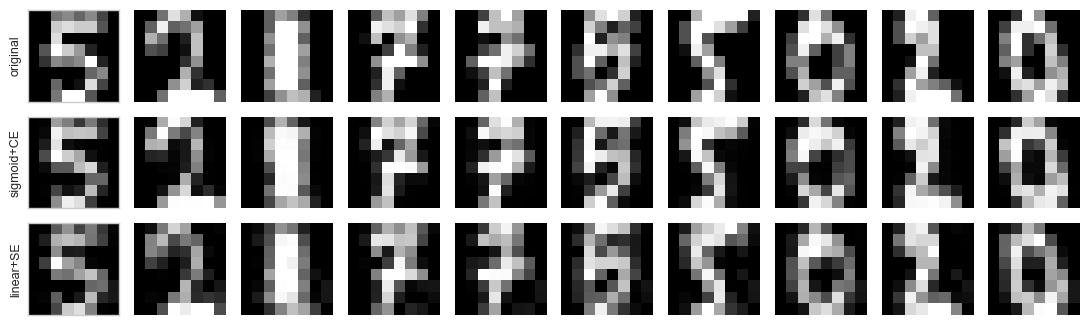

Both recipes reconstruct well; the choice is dictated by the input TYPE (binary vs real),
not by this dataset. Note the squared/linear recipe needed a smaller learning rate.


In [14]:
# Visual comparison: original vs the two reconstructions
sel = rng.choice(len(X), 10, replace=False)
_,_,_,rec_ce = ae_ce.forward(X[sel])
_,_,_,rec_sq = ae_sq.forward(X[sel])
fig, axes = plt.subplots(3, 10, figsize=(11, 3.4))
for j, s in enumerate(sel):
    for row, (img, lab) in enumerate([(X[s], "orig"),
                                      (np.clip(rec_ce[j],0,1), "sigmoid+CE"),
                                      (np.clip(rec_sq[j],0,1), "linear+SE")]):
        axes[row, j].imshow(img.reshape(IMG), cmap="gray"); axes[row, j].axis("off")
        if j == 0: axes[row, j].set_ylabel(lab, fontsize=9)
for row, lab in enumerate(["original", "sigmoid+CE", "linear+SE"]):
    axes[row,0].axis("on"); axes[row,0].set_xticks([]); axes[row,0].set_yticks([])
    axes[row,0].set_ylabel(lab, fontsize=9)
plt.tight_layout(); plt.show()
print("Both recipes reconstruct well; the choice is dictated by the input TYPE (binary vs real),")
print("not by this dataset. Note the squared/linear recipe needed a smaller learning rate.")

## 3. Link between PCA and Autoencoders

> **Claim.** A linear, undercomplete autoencoder trained with squared error *is* PCA.

This holds under **four conditions**: (1) linear encoder $h = Wx$, (2) linear decoder $\hat x = W^{*}h$, (3) squared-error loss, (4) zero-mean (centred) data. Drop any one — e.g. use a sigmoid encoder — and the equivalence breaks.

### The proof

**Step 1 — write the loss as a Frobenius norm.** Stacking codes as rows of $H$ and reconstructions as $HW^{*}$, the objective becomes

$$\min_{W,W^{*}} \; \big\| X - HW^{*} \big\|_F^2, \qquad \|A\|_F^2 = \sum_{i,j} a_{ij}^2 .$$

Writing $\hat X = HW^{*}$ (a **rank-$k$** matrix, since $H$ has $k$ columns), this is exactly

$$\min_{\operatorname{rank}(\hat X)\le k} \; \| X - \hat X \|_F^2 .$$

**Step 2 — Eckart–Young.** The best rank-$k$ approximation of $X$ in Frobenius norm is given by the truncated SVD. With $X = U\Sigma V^{\top}$,

$$\hat X = U_{:,\le k}\,\Sigma_{k}\,V_{:,\le k}^{\top}.$$

**Step 3 — match variables.** Comparing $\hat X = HW^{*}$ with the line above, one valid identification is

$$H = U_{:,\le k}\Sigma_{k}, \qquad W^{*} = V_{:,\le k}^{\top}.$$

**Step 4 — the encoder is linear.** Express $H$ using only $X$ (using $X = U\Sigma V^\top$, $U^\top U = I$, $V^\top V = I$):

$$H = (XX^{\top})(XX^{\top})^{-1}U_{:,\le k}\Sigma_k = \dots = X\,V_{:,\le k}.$$

So $H = X V_{:,\le k}$ is a **linear** map of $X$: the optimal encoder is linear with weights $W = V_{:,\le k}$.

**Step 5 — same eigenvectors.** $V$ holds the eigenvectors of $X^{\top}X$. With the centring normalisation $\tilde x_{ij} = \tfrac{1}{\sqrt m}\big(x_{ij} - \tfrac1m\sum_k x_{kj}\big)$, the matrix $X^{\top}X$ **is** the covariance matrix — whose eigenvectors are exactly the PCA projection directions $P$. Therefore

$$W = V_{:,\le k} = P. \qquad \blacksquare$$

### Numerical verification

By Eckart–Young the optimal rank-$k$ **reconstruction is unique** (when $\lambda_k \neq \lambda_{k+1}$). So the right thing to check is *reconstruction-level* agreement: a linear AE trained by gradient descent should land on the same reconstruction and the same subspace as PCA. (The encoder *rows* need not equal the PCA eigenvectors one-for-one — an untied linear AE only fixes the product $W^{*}W$, so its decoder column space is the quantity that must match.)

In [15]:
k = 10
mu = X.mean(0); Xc = X - mu                      # centre the data (condition 4)

# --- PCA from scratch: eigenvectors of the covariance ---
cov = Xc.T @ Xc / len(Xc)
evals, evecs = np.linalg.eigh(cov)
order = np.argsort(evals)[::-1]
Vk = evecs[:, order[:k]]                          # (64, k) PCA basis
Xhat_pca = Xc @ Vk @ Vk.T
pca_err = np.mean(np.sum((Xc - Xhat_pca)**2, axis=1))

# --- Linear autoencoder trained by gradient descent on CENTERED data ---
lin_ae = Autoencoder(64, k, enc="linear", dec="linear", loss="squared", seed=0)
lin_ae.fit(Xc, epochs=3000, lr=0.3, batch=len(Xc), seed=0)   # full-batch GD to convergence
_,_,_,Xhat_ae = lin_ae.forward(Xc)
ae_err = np.mean(np.sum((Xc - Xhat_ae)**2, axis=1))

# --- compare ---
recon_gap = np.mean(np.sum((Xhat_ae - Xhat_pca)**2, axis=1))   # Eckart-Young uniqueness
def max_principal_angle(A, B):
    Qa,_ = np.linalg.qr(A); Qb,_ = np.linalg.qr(B)
    s = np.linalg.svd(Qa.T @ Qb, compute_uv=False)
    return np.degrees(np.arccos(np.clip(s, -1, 1))).max()
angle = max_principal_angle(lin_ae.Wstar, Vk)     # decoder subspace vs PCA subspace

print(f"PCA            reconstruction error : {pca_err:.5f}")
print(f"linear AE      reconstruction error : {ae_err:.5f}")
print(f"mean ||xhat_AE - xhat_PCA||^2        : {recon_gap:.3e}   (~0  =>  same reconstruction)")
print(f"max principal angle, decoder vs PCA  : {angle:.3f} deg   (~0  =>  same subspace)")

PCA            reconstruction error : 1.22857
linear AE      reconstruction error : 1.22869
mean ||xhat_AE - xhat_PCA||^2        : 1.156e-04   (~0  =>  same reconstruction)
max principal angle, decoder vs PCA  : 0.029 deg   (~0  =>  same subspace)


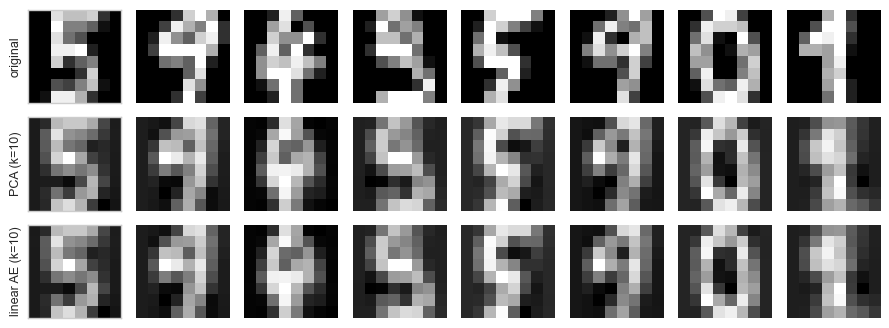

Top-k PCA and a linear squared-error autoencoder produce the same rank-k reconstruction.


In [16]:
# The two reconstructions are visually identical, digit by digit
sel = rng.choice(len(X), 8, replace=False)
fig, axes = plt.subplots(3, 8, figsize=(9, 3.4))
for j, s in enumerate(sel):
    axes[0,j].imshow(X[s].reshape(IMG), cmap="gray")
    axes[1,j].imshow((Xhat_pca[s]+mu).reshape(IMG), cmap="gray")
    axes[2,j].imshow((Xhat_ae[s]+mu).reshape(IMG), cmap="gray")
    for r in range(3): axes[r,j].axis("off")
for r, lab in enumerate(["original", f"PCA (k={k})", f"linear AE (k={k})"]):
    axes[r,0].axis("on"); axes[r,0].set_xticks([]); axes[r,0].set_yticks([]); axes[r,0].set_ylabel(lab, fontsize=9)
plt.tight_layout(); plt.show()
print("Top-k PCA and a linear squared-error autoencoder produce the same rank-k reconstruction.")

## 4. Regularisation in Autoencoders

**Why it is needed.** More parameters $\Rightarrow$ more capacity to overfit. An overcomplete AE ($\dim h \ge \dim x$) can simply copy $x \to h \to \hat x$. Even an *undercomplete* AE can overfit: a $100\times100$ image has $n\approx10^4$ inputs, so a code of $k=1000$ still leaves an enormous parameter count. The cure is to add a complexity penalty $\Omega(\theta)$ and minimise

$$\min_{\theta}\; \underbrace{L_{\text{train}}(\theta)}_{\text{reconstruction}} + \;\Omega(\theta).$$

This single idea — *don't let the training error collapse to zero* — underlies **every** regulariser in chapters 4–7.

### $L_2$ regularisation (weight decay)

$$\widetilde L(\theta) = L(\theta) + \tfrac{\alpha}{2}\|\theta\|^2 \;\Rightarrow\; \nabla \widetilde L = \nabla L + \alpha\theta .$$

Geometrically (diagonalising the Hessian $H = Q\Lambda Q^{\top}$), the regularised optimum is the unregularised one rotated and **shrunk per-direction**:

$$\tilde w = Q\,\operatorname{diag}\!\Big(\tfrac{d_i}{d_i+\alpha}\Big)Q^{\top}w^{*}.$$

High-curvature ("important") directions $d_i \gg \alpha$ are kept ($\tfrac{d_i}{d_i+\alpha}\approx1$); flat, unimportant directions $d_i \ll \alpha$ are killed ($\approx 0$).

### Weight tying

Force the decoder to be the transpose of the encoder, $W^{*} = W^{\top}$. This **halves** the free parameters ($2dk \to dk$) and acts as regularisation: the same directions are used to project *and* to reconstruct.

In [17]:
# Parameter count: tying halves the encoder/decoder weights
d = 64
for k_h in [32, 64, 96]:
    untied = 2*d*k_h
    tied   = d*k_h
    print(f"hidden={k_h:3d}:  untied weights = {untied:5d}   tied weights = {tied:5d}   ({tied/untied:.0%})")

hidden= 32:  untied weights =  4096   tied weights =  2048   (50%)
hidden= 64:  untied weights =  8192   tied weights =  4096   (50%)
hidden= 96:  untied weights = 12288   tied weights =  6144   (50%)


In [18]:
# Train: plain vs L2 vs tied. Compare reconstruction and weight norms.
plain = Autoencoder(64, 64, loss="cross_entropy", seed=5)
l2    = Autoencoder(64, 64, loss="cross_entropy", alpha=1e-3, seed=5)
tied  = Autoencoder(64, 64, loss="cross_entropy", tied=True,  seed=5)
for ae in (plain, l2, tied): ae.fit(X, epochs=300, lr=0.5, batch=128, seed=5)

def wnorm(ae): return np.sqrt(np.sum(ae.W**2))
print(f"{'model':18s}{'recon MSE':>12s}{'||W||':>10s}")
for name, ae in [("plain", plain), ("L2 (a=1e-3)", l2), ("tied W*=W^T", tied)]:
    _,_,_,Xhat = ae.forward(X)
    print(f"{name:18s}{np.mean(np.sum((np.clip(Xhat,0,1)-X)**2,1)):12.4f}{wnorm(ae):10.3f}")
print("\\nL2 shrinks ||W|| (smaller weights); tying reconstructs comparably with half the parameters.")

model                recon MSE     ||W||
plain                   0.2158    34.067
L2 (a=1e-3)             0.2814    27.841
tied W*=W^T             0.2269    43.083
\nL2 shrinks ||W|| (smaller weights); tying reconstructs comparably with half the parameters.


## 5. Denoising Autoencoders

Corrupt the input with a noise process $P(\tilde x_{ij}\mid x_{ij})$ **before** feeding it in, but still grade the network against the **clean** target:

$$\arg\min_{\theta}\; \frac{1}{m}\sum_i \big\| \hat x_i - x_i \big\|^2, \qquad \hat x_i = \text{decode}\big(\text{encode}(\tilde x_i)\big).$$

A common corruption sets each pixel to $0$ with probability $q$ and keeps it otherwise. Now copying no longer works: a copied corrupted pixel won't match the clean target. The network is *forced* to infer a missing pixel from its neighbours — i.e. to learn the data's structure rather than memorise it. As the noise level $q$ rises, the learned filters get **wider** (a neuron must pool more neighbours to be confident).

In [19]:
# Denoising AE: input is masked (40% pixels zeroed), target is the clean image
den = Autoencoder(64, 64, loss="cross_entropy", denoise_p=0.4, denoise_kind="mask", seed=2)
den.fit(X, epochs=300, lr=0.5, batch=128, seed=2)

Xtest = X[:300]
corrupt = Xtest * (rng.random(Xtest.shape) > 0.4)         # same corruption at test time
_,_,_,recon = den.forward(corrupt)
copy_err    = np.mean(np.sum((corrupt - Xtest)**2, 1))    # error if we just kept the corrupted input
denoise_err = np.mean(np.sum((np.clip(recon,0,1) - Xtest)**2, 1))
print(f"error of corrupted input vs clean (no model): {copy_err:.3f}")
print(f"error after denoising reconstruction        : {denoise_err:.3f}")
print(f"the autoencoder recovers ~{(1-denoise_err/copy_err)*100:.0f}% of the corruption damage")

error of corrupted input vs clean (no model): 6.093
error after denoising reconstruction        : 1.870
the autoencoder recovers ~69% of the corruption damage


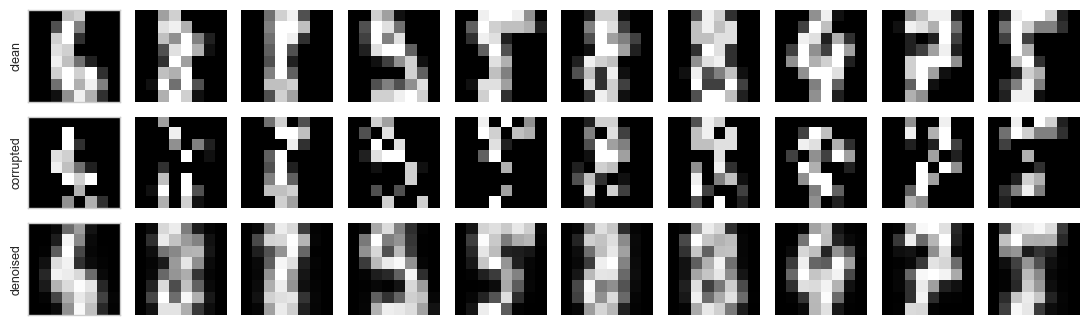

In [20]:
# original  ->  corrupted (40% pixels dropped)  ->  denoised reconstruction
sel = rng.choice(len(Xtest), 10, replace=False)
fig, axes = plt.subplots(3, 10, figsize=(11, 3.4))
for j, s in enumerate(sel):
    axes[0,j].imshow(Xtest[s].reshape(IMG), cmap="gray")
    axes[1,j].imshow(corrupt[s].reshape(IMG), cmap="gray")
    axes[2,j].imshow(np.clip(recon[s],0,1).reshape(IMG), cmap="gray")
    for r in range(3): axes[r,j].axis("off")
for r, lab in enumerate(["clean", "corrupted", "denoised"]):
    axes[r,0].axis("on"); axes[r,0].set_xticks([]); axes[r,0].set_yticks([]); axes[r,0].set_ylabel(lab, fontsize=9)
plt.tight_layout(); plt.show()

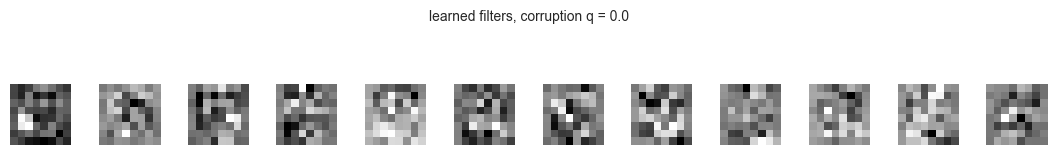

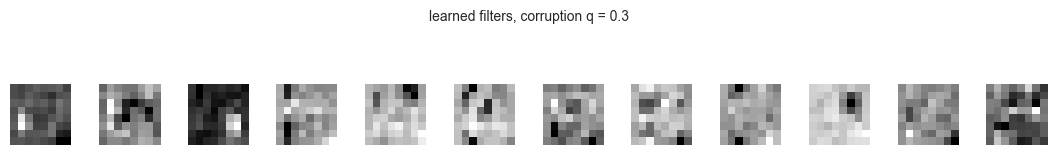

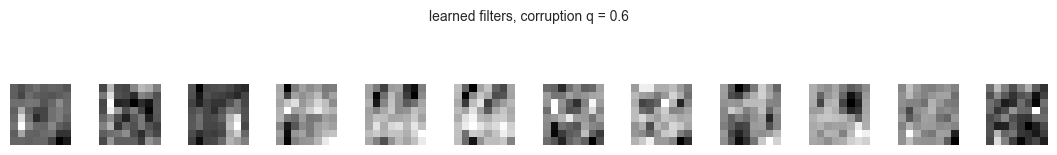

With more noise the filters grow broader: a unit must lean on more neighbouring pixels.


In [21]:
# Filters get WIDER as corruption increases (each row of W reshaped to 8x8)
def show_filters(ae, n=12, title=""):
    W = ae.W[:n]
    W = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-9)   # x_i = w_l / ||w_l|| (max-activating input)
    fig, axes = plt.subplots(1, n, figsize=(n*0.9, 1.2))
    for i, ax in enumerate(axes):
        ax.imshow(W[i].reshape(IMG), cmap="gray"); ax.axis("off")
    fig.suptitle(title, fontsize=10, y=1.25); plt.tight_layout(); plt.show()

for q in [0.0, 0.3, 0.6]:
    ae = Autoencoder(64, 64, loss="cross_entropy", denoise_p=q, denoise_kind="mask", seed=2)
    ae.fit(X, epochs=200, lr=0.5, batch=128, seed=2)
    show_filters(ae, n=12, title=f"learned filters, corruption q = {q}")
print("With more noise the filters grow broader: a unit must lean on more neighbouring pixels.")

## 6. Sparse Autoencoders

A different idea: keep most hidden units **inactive** for any given input. With sigmoid units, define the average activation of unit $l$ over the data

$$\hat\rho_l = \frac{1}{m}\sum_{i=1}^{m} h(x_i)_l ,$$

and push it towards a tiny target $\rho$ (e.g. $0.05$) with a **KL-divergence** penalty between two Bernoullis:

$$\Omega(\theta) = \sum_{l=1}^{k}\Big[\rho\log\frac{\rho}{\hat\rho_l} + (1-\rho)\log\frac{1-\rho}{1-\hat\rho_l}\Big],$$

which is $0$ exactly when $\hat\rho_l = \rho$ and grows sharply otherwise. The full objective is $\widetilde L = L + \beta\,\Omega$. A neuron that fires for *every* input carries no discriminative power; forcing it to fire only sometimes makes it specialise. Even with many hidden units, only a few may switch on per input, so the network can't memorise.

In [22]:
sparse = Autoencoder(64, 64, loss="cross_entropy", rho=0.05, beta=3.0, seed=3)
plain3 = Autoencoder(64, 64, loss="cross_entropy", seed=3)
sparse.fit(X, epochs=400, lr=0.5, batch=128, seed=3)
plain3.fit(X, epochs=400, lr=0.5, batch=128, seed=3)

print(f"target sparsity rho = 0.05")
print(f"sparse AE  mean activation (rho_hat) = {sparse.encode(X).mean():.4f}")
print(f"plain  AE  mean activation           = {plain3.encode(X).mean():.4f}")

target sparsity rho = 0.05
sparse AE  mean activation (rho_hat) = 0.0616
plain  AE  mean activation           = 0.4290


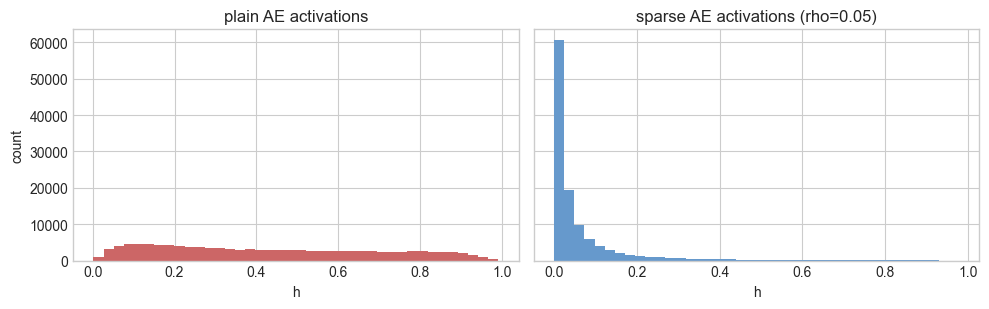

The sparse AE concentrates activations near 0 — most units stay off for any given digit.


In [23]:
# Distribution of hidden activations: sparse AE is pushed toward 0
Hs = sparse.encode(X).ravel()
Hp = plain3.encode(X).ravel()
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
ax[0].hist(Hp, bins=40, color="#cc6666"); ax[0].set_title("plain AE activations"); ax[0].set_xlabel("h")
ax[1].hist(Hs, bins=40, color="#6699cc"); ax[1].set_title("sparse AE activations (rho=0.05)"); ax[1].set_xlabel("h")
ax[0].set_ylabel("count"); plt.tight_layout(); plt.show()
print("The sparse AE concentrates activations near 0 — most units stay off for any given digit.")

## 7. Contractive Autoencoders

The contractive AE adds a penalty on the **Jacobian** of the hidden code with respect to the input:

$$\Omega = \big\| J_x(h) \big\|_F^2 = \sum_{j=1}^{n}\sum_{l=1}^{k}\Big(\frac{\partial h_l}{\partial x_j}\Big)^2 .$$

A small entry $\partial h_l / \partial x_j \approx 0$ means the code is **insensitive** to that input direction. This fights the reconstruction loss, which *needs* $h$ to track input variation. The two objectives pull against each other, and the balance is: $h$ becomes sensitive to **only the important (high-variance) directions** and ignores small, noisy ones — the same geometry as PCA.

For a sigmoid encoder $h_l = \sigma(a_l)$, $a = Wx + b$, the Jacobian entry is $\frac{\partial h_l}{\partial x_j} = h_l(1-h_l)\,W_{lj}$, so the penalty has the clean closed form

$$\Omega = \sum_{l=1}^{k}\big[h_l(1-h_l)\big]^2 \,\|W_l\|^2 ,$$

where $W_l$ is row $l$ of $W$. (That is exactly the `contractive_value` term we gradient-checked above.)

In [24]:
con   = Autoencoder(64, 64, loss="cross_entropy", lam_contractive=0.1, seed=4)
plain4 = Autoencoder(64, 64, loss="cross_entropy", seed=4)
con.fit(X,    epochs=300, lr=0.3, batch=128, seed=4)
plain4.fit(X, epochs=300, lr=0.3, batch=128, seed=4)

print(f"plain       AE  mean ||J||_F^2 = {plain4.contractive_value(X):7.3f}")
print(f"contractive AE  mean ||J||_F^2 = {con.contractive_value(X):7.3f}")
print("The penalty drives the Jacobian norm down: the code resists small input perturbations,")
print("staying sensitive only to the directions that actually matter for reconstruction.")

plain       AE  mean ||J||_F^2 =  35.522
contractive AE  mean ||J||_F^2 =   6.818
The penalty drives the Jacobian norm down: the code resists small input perturbations,
staying sensitive only to the directions that actually matter for reconstruction.


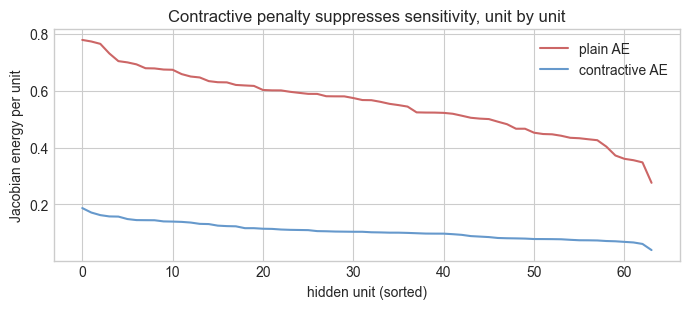

: 

In [ ]:
# Per-unit sensitivity: how much each hidden unit's Jacobian energy shrinks
def per_unit_jac(ae, X):
    H = ae.encode(X)
    return (((H*(1-H))**2).mean(0)) * np.sum(ae.W**2, axis=1)   # length-k vector
jp = np.sort(per_unit_jac(plain4, X))[::-1]
jc = np.sort(per_unit_jac(con,    X))[::-1]
plt.figure(figsize=(7,3.2))
plt.plot(jp, label="plain AE", color="#cc6666")
plt.plot(jc, label="contractive AE", color="#6699cc")
plt.xlabel("hidden unit (sorted)"); plt.ylabel("Jacobian energy per unit"); plt.legend()
plt.title("Contractive penalty suppresses sensitivity, unit by unit"); plt.tight_layout(); plt.show()

## Summary — the big picture (chapters 1–7)

| concept | core idea | formula / switch in our engine |
|---|---|---|
| **Autoencoder** | encode then decode through a bottleneck | $h=g(Wx+b)$, $\hat x=f(W^{*}h+c)$ |
| **Undercomplete** | real bottleneck, compresses like PCA | $\dim h < \dim x$ |
| **Overcomplete** | can learn the identity → needs regularising | $\dim h \ge \dim x$ |
| **Decoder + loss** | binary → sigmoid + cross-entropy; real → linear + squared | `dec`, `loss` |
| **PCA $\equiv$ linear AE** | linear enc/dec + squared loss + centring | $W = V_{:,\le k}$ (eigenvectors of $X^{\top}X$) |
| **$L_2$ / weight decay** | shrink weights per-direction by $\tfrac{d_i}{d_i+\alpha}$ | `alpha` |
| **Weight tying** | $W^{*}=W^{\top}$, half the parameters | `tied=True` |
| **Denoising** | corrupt input, reconstruct clean target | `denoise_p` |
| **Sparse** | keep $\hat\rho_l \approx \rho$ via KL penalty | `rho`, `beta` |
| **Contractive** | penalise $\|J_x(h)\|_F^2$ → keep only important directions | `lam_contractive` |

> *An autoencoder learns a representation; regularisation stops it from cheating. Every regulariser is really one principle — do not let the training error collapse to zero.*

**Next** (chapters 8–18 of the lecture): the bias–variance decomposition, true vs train error, and the rest of the regularisation family (dataset augmentation, label smoothing, early stopping, bagging, dropout) — which generalise the same $\min_\theta\, L_{\text{train}} + \Omega$ idea beyond autoencoders.